# Ottimizzazione dei modelli

In questo notebook verifico se la scelta dei parametri può migliorare i modelli costruiti nel notebook precedente. Mantengo la stessa divisione tra training e test e lo stesso trattamento dei valori mancanti, così il confronto resta coerente.

L'ottimizzazione viene eseguita soltanto sul training set tramite cross-validation. Il test set viene usato una sola volta alla fine, come controllo su dati non utilizzati nella scelta dei parametri.

## 1. Domande dell'esperimento

Voglio rispondere a tre domande:

1. Quale valore di `C` rende più efficace la Logistic Regression?
2. L'aggiunta di caratteristiche polinomiali di grado 2 riduce l'underfitting del modello lineare oppure aumenta l'overfitting?
3. Quale numero di vicini `k` offre il compromesso migliore per KNN?

Non considero automaticamente migliore il modello con la metrica più alta sul singolo test set: do priorità alla prestazione media e alla stabilità osservate nella cross-validation.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from urllib.request import urlopen

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict,
                                     train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures, StandardScaler

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
DATA_URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
COLUMNS = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'age', 'outcome']
FEATURES = COLUMNS[:-1]
INVALID_ZERO_COLUMNS = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']

## 2. Caricamento e preparazione dei dati

Uso il CSV locale quando è disponibile. In questo modo il notebook può essere eseguito anche senza una nuova connessione al sito del dataset; se il file non esiste, utilizzo la stessa fonte pubblica dei notebook precedenti.

In [48]:
local_path = Path('../data/raw/diabetes.csv')
if not local_path.exists():
    local_path = Path('data/raw/diabetes.csv')
if local_path.exists():
    df = pd.read_csv(local_path, header=None, names=COLUMNS)
    print('Dataset caricato dalla copia locale.')
else:
    with urlopen(DATA_URL, timeout=30) as response:
        from io import BytesIO
        df = pd.read_csv(BytesIO(response.read()), header=None, names=COLUMNS)
    print('Dataset caricato dalla fonte pubblica.')

X = df[FEATURES].copy()
y = df['outcome'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Training: {X_train.shape[0]} righe | Test: {X_test.shape[0]} righe')

Dataset caricato dalla copia locale.
Training: 614 righe | Test: 154 righe


## 3. Pipeline comune di preprocessing

Il preprocessing è inserito nelle pipeline e viene rifatto dentro ogni suddivisione della cross-validation. In questo modo la mediana e i parametri dello scaling non vengono calcolati utilizzando dati di validazione o di test.

Per la versione polinomiale aggiungo i termini di grado 2 dopo l'imputazione e prima della standardizzazione. La standardizzazione è importante perché Logistic Regression regolarizzata e KNN sono sensibili alla scala delle variabili.

In [49]:
def replace_invalid_zeros(frame):
    frame = frame.copy()
    frame[INVALID_ZERO_COLUMNS] = frame[INVALID_ZERO_COLUMNS].replace(0, np.nan)
    return frame

def preprocessing_steps():
    return [
        ('invalid_zeros', FunctionTransformer(replace_invalid_zeros, validate=False)),
        ('imputer', SimpleImputer(strategy='median')),
    ]

def logistic_pipeline(polynomial=False):
    steps = preprocessing_steps()
    if polynomial:
        steps.append(('polynomial', PolynomialFeatures(degree=2, include_bias=False)))
    steps.extend([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ])
    return Pipeline(steps)

def knn_pipeline():
    return Pipeline(preprocessing_steps() + [
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier()),
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 4. Tuning della Logistic Regression lineare

Cerco il valore di `C` usando la ROC-AUC media come criterio di selezione. La ROC-AUC non è migliore di accuracy, precision, recall o F1: misura un aspetto diverso, cioè la capacità del modello di separare le due classi considerando molte soglie. La uso nel tuning perché non dipende da una sola soglia decisionale; nella valutazione finale considero comunque tutte le metriche, dando particolare importanza a recall e F1. `C` è l'inverso della forza della regolarizzazione: un valore piccolo penalizza maggiormente i coefficienti e può ridurre l'overfitting, mentre un valore grande lascia più libertà al modello. Valuto anche `class_weight='balanced'`. Il dataset contiene meno osservazioni positive che negative; questa impostazione assegna quindi un peso maggiore agli errori commessi sulla classe positiva durante l'addestramento. Può aumentare il recall, ma talvolta riduce precision e accuracy.

Miglior C: 0.1
ROC-AUC media: 0.845


,C,Pesi classi,ROC-AUC validazione,Deviazione standard,ROC-AUC training
0,0.01,None,0.840386,0.012016,0.846222
1,0.01,balanced,0.840511,0.011256,0.846164
2,0.10,None,0.844387,0.016045,0.851135
3,0.10,balanced,0.844994,0.013035,0.851775
4,1.00,None,0.843364,0.018550,0.851091
5,1.00,balanced,0.844381,0.016074,0.851998
6,10.00,None,0.843304,0.018815,0.850945
7,10.00,balanced,0.843909,0.016907,0.852027
8,100.00,None,0.843304,0.018815,0.850920
9,100.00,balanced,0.843732,0.017082,0.852023


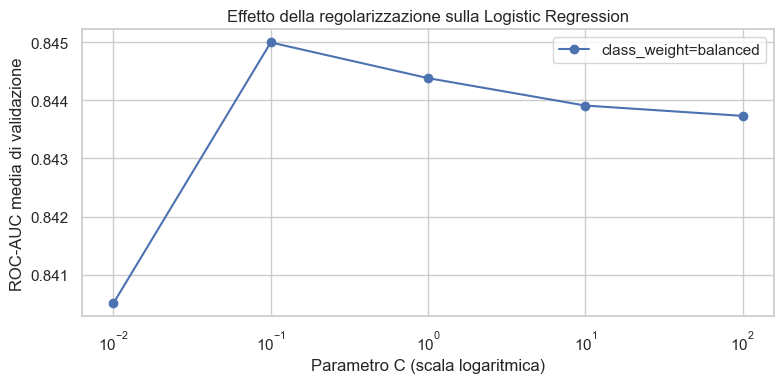

In [50]:
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__class_weight': [None, 'balanced'],
}
search_lr = GridSearchCV(
    logistic_pipeline(), param_grid_lr, scoring='roc_auc', cv=cv,
    n_jobs=-1, return_train_score=True
)
search_lr.fit(X_train, y_train)
print('Miglior C:', search_lr.best_params_['classifier__C'])
print('ROC-AUC media:', round(search_lr.best_score_, 4))

lr_results = pd.DataFrame(search_lr.cv_results_)[[
    'param_classifier__C', 'param_classifier__class_weight', 'mean_test_score', 'std_test_score', 'mean_train_score'
]]
lr_results.rename(columns={
    'param_classifier__C': 'C', 'param_classifier__class_weight': 'Pesi classi', 'mean_test_score': 'ROC-AUC validazione',
    'std_test_score': 'Deviazione standard', 'mean_train_score': 'ROC-AUC training'
}, inplace=True)
display(lr_results)

plt.figure(figsize=(8, 4))
for weights, group in lr_results.groupby('Pesi classi'):
    plt.plot(group['C'], group['ROC-AUC validazione'], marker='o', label=f'class_weight={weights}')
plt.xscale('log')
plt.xlabel('Parametro C (scala logaritmica)')
plt.ylabel('ROC-AUC media di validazione')
plt.title('Effetto della regolarizzazione sulla Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Confronto tra modello lineare e modello polinomiale

Il modello polinomiale non è una Logistic Regression completamente diversa: amplia le variabili disponibili aggiungendo potenze e interazioni, poi applica la stessa classificazione logistica. Confronto la versione lineare con i gradi 2 e 3 usando la stessa procedura di cross-validation. Il grado 3 è un controllo utile, ma la complessità cresce rapidamente e potrebbe produrre overfitting.

Se la prestazione sul training cresce molto ma quella di validazione non cresce, il modello sta probabilmente imparando dettagli specifici del training set invece di generalizzare.

In [51]:
param_grid_poly = {
    'polynomial': ['passthrough', PolynomialFeatures(degree=2, include_bias=False), PolynomialFeatures(degree=3, include_bias=False)],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__class_weight': [None, 'balanced'],
}
# La pipeline polinomiale viene definita separatamente per evitare di sostituire
# uno step con un oggetto non compatibile durante la ricerca.
poly_search_pipeline = Pipeline([
    ('invalid_zeros', FunctionTransformer(replace_invalid_zeros, validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
    ('polynomial', 'passthrough'),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
])
poly_search = GridSearchCV(
    poly_search_pipeline, param_grid_poly, scoring='roc_auc', cv=cv,
    n_jobs=-1, return_train_score=True
)
poly_search.fit(X_train, y_train)
print('Migliori parametri:', poly_search.best_params_)
print('ROC-AUC media:', round(poly_search.best_score_, 4))

poly_results = pd.DataFrame(poly_search.cv_results_)[[
    'param_polynomial', 'param_classifier__C', 'mean_test_score', 'std_test_score'
]]
poly_results.rename(columns={
    'param_polynomial': 'Trasformazione', 'param_classifier__C': 'C', 'param_classifier__class_weight': 'Pesi classi',
    'mean_test_score': 'ROC-AUC media', 'std_test_score': 'Deviazione standard'
}, inplace=True)
poly_results['Trasformazione'] = poly_results['Trasformazione'].map(
    lambda value: 'Lineare' if value == 'passthrough' else f'Polinomiale grado {value.degree}'
)
display(poly_results.sort_values('ROC-AUC media', ascending=False).head(10))

Migliori parametri: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'polynomial': PolynomialFeatures(include_bias=False)}
ROC-AUC media: 0.8462


,Trasformazione,C,ROC-AUC media,Deviazione standard
10,Polinomiale grado 2,0.10,0.846238,0.019476
7,Polinomiale grado 2,0.10,0.846053,0.019784
13,Polinomiale grado 2,1.00,0.845688,0.023749
5,Polinomiale grado 3,0.01,0.845245,0.018415
9,Lineare,0.10,0.844994,0.013035
2,Polinomiale grado 3,0.01,0.844647,0.019538
16,Polinomiale grado 2,1.00,0.844421,0.023215
6,Lineare,0.10,0.844387,0.016045
15,Lineare,1.00,0.844381,0.016074
21,Lineare,10.00,0.843909,0.016907


## 6. Tuning del numero di vicini di KNN

In KNN il parametro `k` stabilisce quante osservazioni vicine partecipano alla decisione. Con un `k` piccolo il modello è più flessibile e sensibile al rumore; con un `k` grande produce una frontiera più stabile ma può perdere dettagli.

Non scelgo automaticamente la radice del numero di osservazioni: può essere un punto di partenza, ma il valore più adatto dipende dai dati e va verificato con cross-validation.

Miglior k: 41
ROC-AUC media: 0.8327


,k,ROC-AUC validazione,Deviazione standard,ROC-AUC training
0,3,0.764294,0.060383,0.923572
1,5,0.784332,0.037281,0.906112
2,7,0.798276,0.032941,0.893631
3,9,0.814684,0.029654,0.884896
4,11,0.822103,0.029919,0.883121
5,15,0.831831,0.029821,0.875966
6,21,0.831100,0.034621,0.865477
7,31,0.830589,0.029252,0.851246
8,41,0.832746,0.022307,0.848793


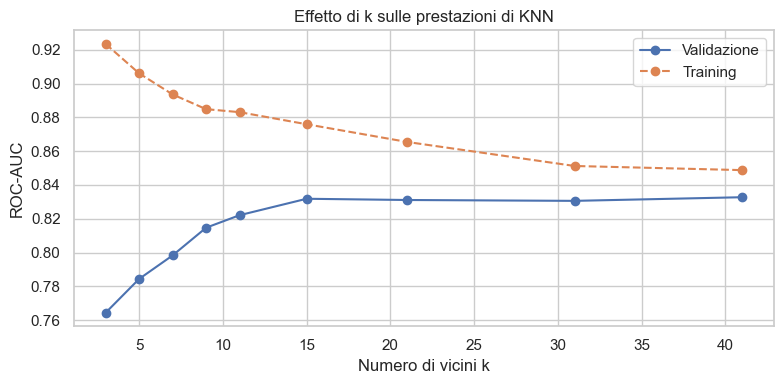

In [52]:
param_grid_knn = {'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31, 41]}
search_knn = GridSearchCV(
    knn_pipeline(), param_grid_knn, scoring='roc_auc', cv=cv,
    n_jobs=-1, return_train_score=True
)
search_knn.fit(X_train, y_train)
print('Miglior k:', search_knn.best_params_['classifier__n_neighbors'])
print('ROC-AUC media:', round(search_knn.best_score_, 4))

knn_results = pd.DataFrame(search_knn.cv_results_)[[
    'param_classifier__n_neighbors', 'mean_test_score', 'std_test_score', 'mean_train_score'
]]
knn_results.rename(columns={
    'param_classifier__n_neighbors': 'k', 'mean_test_score': 'ROC-AUC validazione',
    'std_test_score': 'Deviazione standard', 'mean_train_score': 'ROC-AUC training'
}, inplace=True)
display(knn_results)

plt.figure(figsize=(8, 4))
plt.plot(knn_results['k'], knn_results['ROC-AUC validazione'], marker='o', label='Validazione')
plt.plot(knn_results['k'], knn_results['ROC-AUC training'], marker='o', linestyle='--', label='Training')
plt.xlabel('Numero di vicini k')
plt.ylabel('ROC-AUC')
plt.title('Effetto di k sulle prestazioni di KNN')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Valutazione finale sul test set

Dopo aver scelto i parametri usando esclusivamente il training set, valuto sul test set il modello lineare ottimizzato, il miglior modello polinomiale e il miglior KNN. Questa è la prima volta in cui il test set entra nel confronto finale.

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modello,,,,,
Logistic Regression lineare ottimizzata,0.708,0.571,0.667,0.615,0.810
Logistic Regression polinomiale grado 2,0.734,0.607,0.685,0.643,0.825
KNN ottimizzato,0.740,0.667,0.519,0.583,0.805


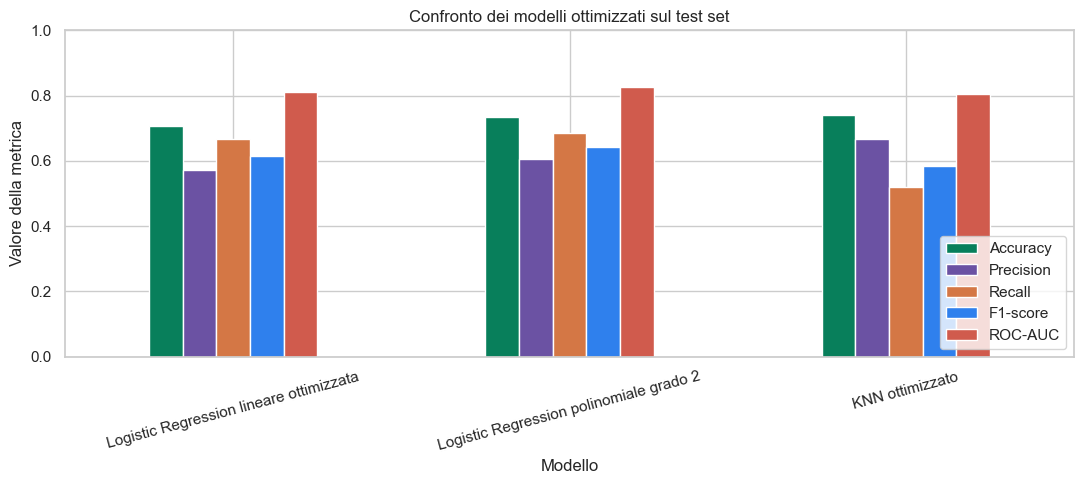

In [53]:
best_lr = search_lr.best_estimator_
best_poly = poly_search.best_estimator_
best_knn = search_knn.best_estimator_

def test_metrics(name, model):
    model.fit(X_train, y_train)
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    return {
        'Modello': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1-score': f1_score(y_test, predictions, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, probabilities),
    }

tuned_results = pd.DataFrame([
    test_metrics('Logistic Regression lineare ottimizzata', best_lr),
    test_metrics('Logistic Regression polinomiale grado 2', best_poly),
    test_metrics('KNN ottimizzato', best_knn),
]).set_index('Modello').round(3)
display(tuned_results)

tuned_results[['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']].plot(
    kind='bar', figsize=(11, 5), ylim=(0, 1), rot=15,
    color=['#087f5b', '#6b52a3', '#d47745', '#2f80ed', '#d05b4d']
)
plt.title('Confronto dei modelli ottimizzati sul test set')
plt.ylabel('Valore della metrica')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Visualizzazione delle frontiere decisionali

Per rendere intuitiva la differenza tra i modelli, visualizzo le predizioni variando soltanto glucosio e BMI. Le altre sei variabili vengono mantenute costanti al loro valore mediano. Il grafico è quindi una proiezione bidimensionale di un problema a otto dimensioni: aiuta a interpretare la forma delle frontiere, ma non rappresenta da solo tutte le decisioni del modello.


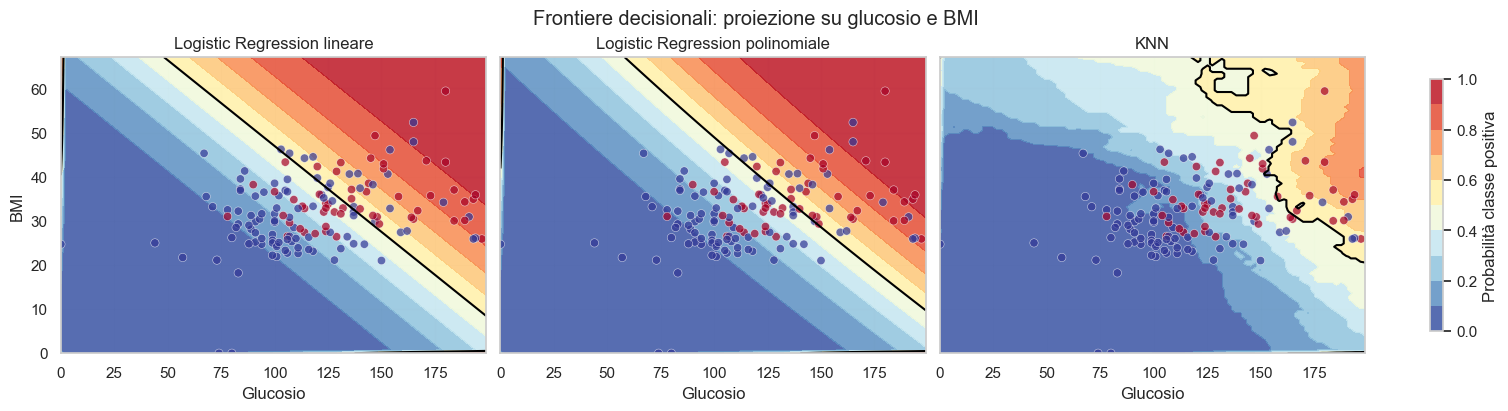

In [54]:
plot_features = ['glucose', 'bmi']
grid_glucose = np.linspace(X['glucose'].min(), X['glucose'].max(), 90)
grid_bmi = np.linspace(X['bmi'].min(), X['bmi'].max(), 90)
mesh_glucose, mesh_bmi = np.meshgrid(grid_glucose, grid_bmi)
mesh = pd.DataFrame({feature: X[feature].median() for feature in FEATURES}, index=range(mesh_glucose.size))
mesh['glucose'] = mesh_glucose.ravel()
mesh['bmi'] = mesh_bmi.ravel()

models_for_plot = {
    'Logistic Regression lineare': best_lr,
    'Logistic Regression polinomiale': best_poly,
    'KNN': best_knn,
}
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True, constrained_layout=True)
for ax, (name, model) in zip(axes, models_for_plot.items()):
    probabilities = model.predict_proba(mesh)[:, 1].reshape(mesh_glucose.shape)
    contour = ax.contourf(mesh_glucose, mesh_bmi, probabilities, levels=np.linspace(0, 1, 11), cmap='RdYlBu_r', alpha=.85)
    ax.contour(mesh_glucose, mesh_bmi, probabilities, levels=[.5], colors='black', linewidths=1.5)
    ax.scatter(X_test['glucose'], X_test['bmi'], c=y_test, cmap='RdYlBu_r', edgecolor='white', linewidth=.4, alpha=.7)
    ax.set_title(name)
    ax.set_xlabel('Glucosio')
    ax.grid(alpha=.2)
axes[0].set_ylabel('BMI')
fig.colorbar(contour, ax=axes, label='Probabilità classe positiva', shrink=.85)
fig.suptitle('Frontiere decisionali: proiezione su glucosio e BMI')
plt.show()

## 9. Analisi della soglia decisionale

La soglia predefinita di 0,5 trasforma la probabilità in classe. In un problema di supporto alla valutazione del rischio una soglia più bassa può individuare più casi positivi, accettando però un aumento dei falsi positivi.

Per non usare il test set nella scelta della soglia, calcolo probabilità out-of-fold sul training set con `cross_val_predict`. La soglia viene quindi analizzata su predizioni ottenute da dati che il modello non aveva visto durante ciascun fold. Nel progetto mantengo la soglia standard di 0,5: nel nostro esperimento offre il miglior compromesso tra precision e recall e il valore più alto di F1-score. Una soglia più bassa aumenterebbe il recall, ma produrrebbe più falsi positivi e una precisione inferiore.

,Soglia,Precision,Recall,F1-score
0,0.3,0.519,0.897,0.658
1,0.4,0.579,0.804,0.673
2,0.5,0.662,0.706,0.683
3,0.6,0.732,0.626,0.675
4,0.7,0.740,0.519,0.610


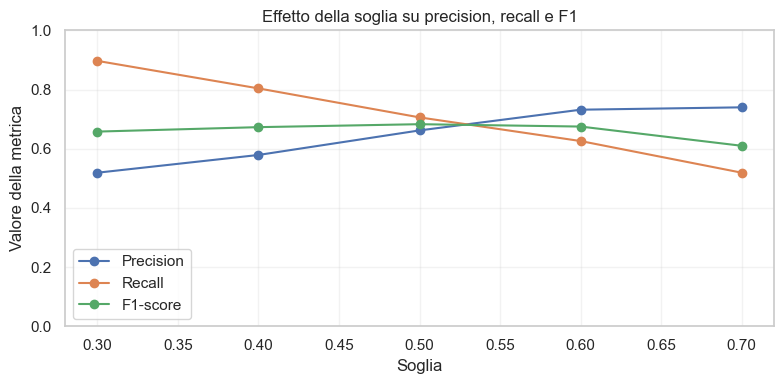

In [55]:
oof_probabilities = cross_val_predict(
    best_poly, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]
threshold_rows = []
for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    predictions = (oof_probabilities >= threshold).astype(int)
    threshold_rows.append({
        'Soglia': threshold,
        'Precision': precision_score(y_train, predictions, zero_division=0),
        'Recall': recall_score(y_train, predictions, zero_division=0),
        'F1-score': f1_score(y_train, predictions, zero_division=0),
    })
threshold_results = pd.DataFrame(threshold_rows).round(3)
display(threshold_results)

threshold_results.set_index('Soglia').plot(kind='line', marker='o', figsize=(8, 4), ylim=(0, 1))
plt.title('Effetto della soglia su precision, recall e F1')
plt.ylabel('Valore della metrica')
plt.grid(alpha=.25)
plt.tight_layout()
plt.show()

## 10. Conclusioni

Dai risultati ottenuti, la configurazione migliore nella cross-validation è la Logistic Regression polinomiale di grado 2 con `C=0,1` e `class_weight='balanced'` (ROC-AUC media 0,846). La Logistic Regression lineare ottimizzata raggiunge 0,845, mentre KNN raggiunge 0,833 con `k=41`. Il grado 3 non supera il grado 2, quindi la complessità aggiuntiva non è giustificata.

Sul test set KNN mantiene l'accuracy più alta (0,740), ma il modello polinomiale ottiene un recall più alto (0,685), F1-score 0,643 e ROC-AUC 0,825. La scelta dipende quindi dall'obiettivo: se voglio ridurre i casi positivi non riconosciuti, preferisco la Logistic Regression polinomiale con pesi bilanciati; se considero soltanto l'accuracy, KNN risulta leggermente superiore.

L'opzione `class_weight='balanced'` ha aumentato il peso della classe meno numerosa. Questo spiega il recall più alto, ma non rende il modello clinicamente affidabile. I risultati restano legati a un dataset piccolo e specifico e devono essere interpretati come esperimento didattico.

In [56]:
cv_summary = pd.DataFrame({
    'Logistic Regression lineare': [search_lr.best_score_],
    'Logistic Regression polinomiale': [poly_search.best_score_],
    'KNN': [search_knn.best_score_],
}, index=['ROC-AUC media cross-validation']).T.round(3)
display(cv_summary.sort_values('ROC-AUC media cross-validation', ascending=False))

best_cv_model = cv_summary['ROC-AUC media cross-validation'].idxmax()
print(f'Modello con ROC-AUC media più alta: {best_cv_model}')
print('La scelta va verificata insieme a recall, precision, F1-score e differenza tra training e validazione.')

,ROC-AUC media cross-validation
Logistic Regression polinomiale,0.846
Logistic Regression lineare,0.845
KNN,0.833


Modello con ROC-AUC media più alta: Logistic Regression polinomiale
La scelta va verificata insieme a recall, precision, F1-score e differenza tra training e validazione.


## 11. Configurazione scelta

> **Modello operativo scelto**
>
> **Logistic Regression polinomiale, grado 2** · `C=0,1` · `class_weight='balanced'` · soglia `0,5`

Questa configurazione ha ottenuto la ROC-AUC media più alta nella cross-validation (**0,846**) e, sul test set, accuracy **0,734**, precision **0,607**, recall **0,685**, F1-score **0,643** e ROC-AUC **0,825**. La Logistic Regression lineare ottimizzata ha ottenuto accuracy 0,708, precision 0,571, recall 0,667, F1-score 0,615 e ROC-AUC 0,810. KNN ha ottenuto accuracy leggermente più alta (0,740) e precision 0,667, ma un recall più basso (0,519) e F1-score 0,583, quindi riconosce meno casi positivi.

La soglia operativa rimane 0,5. L'analisi delle soglie mostra che abbassarla a 0,3 o 0,4 aumenta il recall, ma riduce la precision; la soglia 0,5 produce il miglior F1-score nelle predizioni out-of-fold. Questa scelta è un compromesso trasparente e potrà essere modificata in futuro se l'obiettivo diventasse privilegiare ulteriormente il recall.

Questa configurazione rappresenta il risultato dell'esperimento di ottimizzazione. Prima di utilizzarla nell'applicazione, la riporterò nello script di training mantenendo lo stesso preprocessing e la stessa soglia decisionale.